# Deep learning for computer vision


This notebook will teach you to build and train convolutional networks for image recognition. Brace yourselves.

# CIFAR dataset
This week, we shall focus on the image recognition problem on cifar10 dataset
* 60k images of shape 3x32x32
* 10 different classes: planes, dogs, cats, trucks, etc.

<img src="https://github.com/yandexdataschool/deep_vision_and_graphics/blob/fall22/week02-convnets/cifar10.jpg?raw=1" style="width:80%">

In [17]:
# **IMPORTANT** when running in colab, un-comment this
from pathlib import Path
from torchvision.datasets import CIFAR10

data_path = Path('cifar_data')
dataset = CIFAR10(str(data_path), train=True, download=True)
del dataset

In [18]:
import numpy as np
from cifar import load_cifar10
X_train, y_train, X_val, y_val, X_test, y_test = load_cifar10("cifar_data")

class_names = np.array(['airplane', 'automobile', 'bird', 'cat', 'deer','dog', 'frog', 'horse', 'ship', 'truck'])

print(X_train.shape,y_train.shape)

(40000, 3, 32, 32) (40000,)


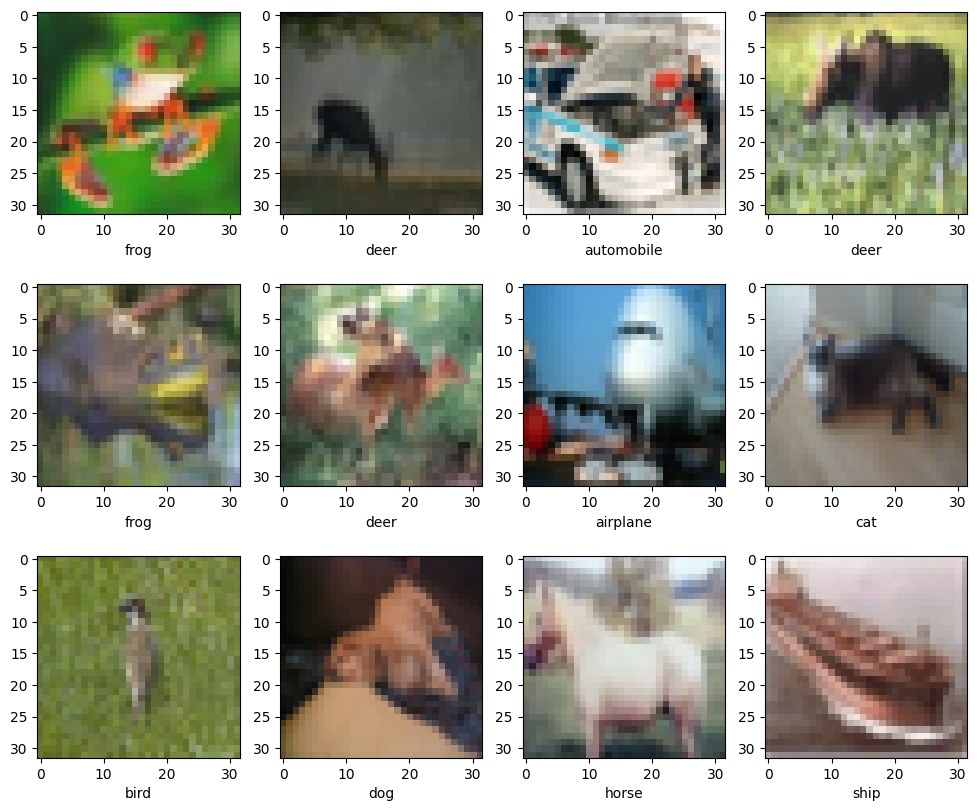

In [19]:
import matplotlib.pyplot as plt
%matplotlib inline

plt.figure(figsize=[12,10])
for i in range(12):
    plt.subplot(3,4,i+1)
    plt.xlabel(class_names[y_train[i]])
    plt.imshow(np.transpose(X_train[i],[1,2,0]))

# Building a network

Simple neural networks with layers applied on top of one another can be implemented as `torch.nn.Sequential` - just add a list of pre-built modules and let it train.

Let's start with a dense network for our baseline, then gradually improve it.

In [20]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import random
import copy

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

set_seed()
torch.set_num_threads(4)
device = torch.device('cuda' if torch.cuda.is_available() else
                      'mps' if torch.backends.mps.is_available() else 'cpu')
print('device:', device)

model = nn.Sequential(
    nn.Flatten(),  # reshape images to vectors; if you have conv / pool layers, they go BEFORE flatten
    nn.Linear(3 * 32 * 32, 128),
    nn.ReLU(),
    nn.Linear(128, 10) # logits for 10 classes. No softmax - this is intentional
).to(device)

device: mps


As in our basic tutorial, we train our model with negative log-likelihood aka crossentropy.

In [21]:
# normalized copies of the arrays and leave the original images unchanged
means = np.array((0.4914, 0.4822, 0.4465), dtype=np.float32)
stds = np.array((0.2023, 0.1994, 0.2010), dtype=np.float32)
X_train_normalized = (X_train - means[None, :, None, None]) / stds[None, :, None, None]
X_val_normalized = (X_val - means[None, :, None, None]) / stds[None, :, None, None]

def compute_loss(X_batch, y_batch):
    X_batch = torch.as_tensor(X_batch, dtype=torch.float32, device=device)
    y_batch = torch.as_tensor(y_batch, dtype=torch.int64, device=device)
    logits = model(X_batch)
    return F.cross_entropy(logits, y_batch).mean()

In [22]:
# example
compute_loss(X_train_normalized[:5], y_train[:5])

tensor(2.4641, device='mps:0', grad_fn=<MeanBackward0>)

### Training on minibatches
* We got 40k images, that's way too many for a full-batch SGD. Let's train on minibatches instead
* Below is a function that splits the training sample into minibatches

In [23]:
opt = torch.optim.SGD(model.parameters(), lr=0.01)

train_loss = []
val_accuracy = []

# An auxilary function that returns mini-batches for neural network training
def iterate_minibatches(X, y, batchsize):
    indices = np.random.permutation(np.arange(len(X)))
    for start in range(0, len(indices), batchsize):
        ix = indices[start: start + batchsize]
        yield X[ix], y[ix]

# collected the validation scores and keep the best model in memory
results = []
best_accuracy = -1.0
best_model = None

In [24]:
# kept the original training loop for this experiment
import time
num_epochs = 10 # total amount of full passes over training data
batch_size = 128  # number of samples processed in one SGD iteration
loss_history = []
accuracy_history = []
experiment_best = 0.0

for epoch in range(num_epochs):
    # In each epoch, we do a full pass over the training data:
    start_time = time.time()
    train_loss = []
    val_accuracy = []
    model.train(True) # enable dropout / batch_norm training behavior
    for X_batch, y_batch in iterate_minibatches(X_train_normalized, y_train, batch_size):
        # train on batch
        loss = compute_loss(X_batch, y_batch)
        loss.backward()
        opt.step()
        opt.zero_grad()
        train_loss.append(loss.item() * len(y_batch))  # .item() = convert 1-value Tensor to float

    # And a full pass over the validation data:
    model.train(False)     # disable dropout / use averages for batch_norm
    with torch.no_grad():  # do not store intermediate activations
        for X_batch, y_batch in iterate_minibatches(X_val_normalized, y_val, batch_size):
            logits = model(torch.as_tensor(X_batch, dtype=torch.float32, device=device))
            y_pred = logits.argmax(-1).detach().cpu().numpy()
            val_accuracy.append(np.sum(y_batch == y_pred))

    # counted samples so the smaller last batch has the right weight
    epoch_loss = np.sum(train_loss) / len(X_train)
    epoch_accuracy = np.sum(val_accuracy) / len(X_val)
    loss_history.append(epoch_loss)
    accuracy_history.append(epoch_accuracy)
    experiment_best = max(experiment_best, epoch_accuracy)
    # kept the best model in memory and choose it using validation only
    if epoch_accuracy > best_accuracy:
        best_accuracy = epoch_accuracy
        best_model = copy.deepcopy(model)
        best_name = 'dense'
        best_epoch = epoch + 1

    # Then we print the results for this epoch:
    print("Epoch {} of {} took {:.3f}s".format(
        epoch + 1, num_epochs, time.time() - start_time))
    print("  training loss (in-iteration): \t{:.6f}".format(epoch_loss))
    print("  validation accuracy: \t\t\t{:.2f} %".format(epoch_accuracy * 100))

results.append(('dense', experiment_best))

Epoch 1 of 10 took 1.150s
  training loss (in-iteration): 	1.836419
  validation accuracy: 			40.77 %
Epoch 2 of 10 took 0.989s
  training loss (in-iteration): 	1.638903
  validation accuracy: 			44.33 %
Epoch 3 of 10 took 0.956s
  training loss (in-iteration): 	1.563077
  validation accuracy: 			45.46 %
Epoch 4 of 10 took 1.148s
  training loss (in-iteration): 	1.511136
  validation accuracy: 			46.70 %
Epoch 5 of 10 took 0.950s
  training loss (in-iteration): 	1.470435
  validation accuracy: 			47.26 %
Epoch 6 of 10 took 0.975s
  training loss (in-iteration): 	1.434503
  validation accuracy: 			47.85 %
Epoch 7 of 10 took 0.950s
  training loss (in-iteration): 	1.401784
  validation accuracy: 			49.01 %
Epoch 8 of 10 took 1.143s
  training loss (in-iteration): 	1.371641
  validation accuracy: 			49.09 %
Epoch 9 of 10 took 0.989s
  training loss (in-iteration): 	1.344353
  validation accuracy: 			49.54 %
Epoch 10 of 10 took 1.106s
  training loss (in-iteration): 	1.318901
  validation 

Don't wait for full 100 epochs. You can interrupt training after 5-20 epochs once validation accuracy stops going up.
```

```

```

```

```

```

```

```

```

```

### Final test

In [25]:
# the original final test block is moved below all experiments
# used validation here so the test does not influence model selection
print(f'dense baseline validation accuracy: {experiment_best:.2%}')

dense baseline validation accuracy: 49.83%


## Task I: small convolution net
### First step

Let's create a mini-convolutional network with roughly such architecture:
* Input layer
* 3x3 convolution with 10 filters and _ReLU_ activation
* 2x2 pooling (or set previous convolution stride to 3)
* Flatten
* Dense layer with 100 neurons and _ReLU_ activation
* 10% dropout
* Output dense layer.


__Convolutional layers__ in torch are just like all other layers, but with a specific set of parameters:

__`...`__

__`model.add_module('conv1', nn.Conv2d(in_channels=3, out_channels=10, kernel_size=3)) # convolution`__

__`model.add_module('pool1', nn.MaxPool2d(2)) # max pooling 2x2`__

__`...`__


Once you're done (and compute_loss no longer raises errors), train it with __Adam__ optimizer with default params (feel free to modify the code above).

If everything is right, you should get at least __50%__ validation accuracy.

In [ ]:
# built the small cnn from task I
set_seed()
model = nn.Sequential(
    nn.Conv2d(3, 10, kernel_size=3),
    nn.ReLU(),
    nn.MaxPool2d(2),
    nn.Flatten(),
    nn.Linear(10 * 15 * 15, 100),
    nn.ReLU(),
    nn.Dropout(0.1),
    nn.Linear(100, 10)
).to(device)
opt = torch.optim.Adam(model.parameters(), lr=0.001)

In [27]:
# kept the original training loop for this experiment
import time
num_epochs = 10 # total amount of full passes over training data
batch_size = 128  # number of samples processed in one SGD iteration
loss_history = []
accuracy_history = []
experiment_best = 0.0

for epoch in range(num_epochs):
    # In each epoch, we do a full pass over the training data:
    start_time = time.time()
    train_loss = []
    val_accuracy = []
    model.train(True) # enable dropout / batch_norm training behavior
    for X_batch, y_batch in iterate_minibatches(X_train_normalized, y_train, batch_size):
        # train on batch
        loss = compute_loss(X_batch, y_batch)
        loss.backward()
        opt.step()
        opt.zero_grad()
        train_loss.append(loss.item() * len(y_batch))  # .item() = convert 1-value Tensor to float

    # And a full pass over the validation data:
    model.train(False)     # disable dropout / use averages for batch_norm
    with torch.no_grad():  # do not store intermediate activations
        for X_batch, y_batch in iterate_minibatches(X_val_normalized, y_val, batch_size):
            logits = model(torch.as_tensor(X_batch, dtype=torch.float32, device=device))
            y_pred = logits.argmax(-1).detach().cpu().numpy()
            val_accuracy.append(np.sum(y_batch == y_pred))

    # counted samples so the smaller last batch has the right weight
    epoch_loss = np.sum(train_loss) / len(X_train)
    epoch_accuracy = np.sum(val_accuracy) / len(X_val)
    loss_history.append(epoch_loss)
    accuracy_history.append(epoch_accuracy)
    experiment_best = max(experiment_best, epoch_accuracy)
    # kept the best model in memory and choose it using validation only
    if epoch_accuracy > best_accuracy:
        best_accuracy = epoch_accuracy
        best_model = copy.deepcopy(model)
        best_name = 'small_cnn'
        best_epoch = epoch + 1

    # Then we print the results for this epoch:
    print("Epoch {} of {} took {:.3f}s".format(
        epoch + 1, num_epochs, time.time() - start_time))
    print("  training loss (in-iteration): \t{:.6f}".format(epoch_loss))
    print("  validation accuracy: \t\t\t{:.2f} %".format(epoch_accuracy * 100))

results.append(('small_cnn', experiment_best))

Epoch 1 of 10 took 3.166s
  training loss (in-iteration): 	1.552164
  validation accuracy: 			53.07 %
Epoch 2 of 10 took 1.925s
  training loss (in-iteration): 	1.261929
  validation accuracy: 			57.90 %
Epoch 3 of 10 took 1.843s
  training loss (in-iteration): 	1.146194
  validation accuracy: 			58.04 %
Epoch 4 of 10 took 1.912s
  training loss (in-iteration): 	1.065043
  validation accuracy: 			58.92 %
Epoch 5 of 10 took 2.057s
  training loss (in-iteration): 	1.008111
  validation accuracy: 			60.73 %
Epoch 6 of 10 took 2.065s
  training loss (in-iteration): 	0.941305
  validation accuracy: 			61.66 %
Epoch 7 of 10 took 2.553s
  training loss (in-iteration): 	0.889714
  validation accuracy: 			61.66 %
Epoch 8 of 10 took 2.023s
  training loss (in-iteration): 	0.841334
  validation accuracy: 			62.21 %
Epoch 9 of 10 took 2.146s
  training loss (in-iteration): 	0.794220
  validation accuracy: 			62.51 %
Epoch 10 of 10 took 1.802s
  training loss (in-iteration): 	0.749736
  validation 

```

```

```

```

```

```

```

```

```

```

__Hint:__ If you don't want to compute shapes by hand, just plug in any shape (e.g. 1 unit) and run compute_loss. You will see something like this:

__`RuntimeError: size mismatch, m1: [5 x 1960], m2: [1 x 64] at /some/long/path/to/torch/operation`__

See the __1960__ there? That's your actual input shape.

## Task 2: adding normalization

* Add batch norm (with default params) between convolution and ReLU
  * nn.BatchNorm*d (1d for dense, 2d for conv)
  * usually better to put them after linear/conv but before nonlinearity
* Re-train the network with the same optimizer, it should get at least 60% validation accuracy at peak.



In [28]:
# added batch normalization between the convolution and relu
set_seed()
model = nn.Sequential(
    nn.Conv2d(3, 10, kernel_size=3),
    nn.BatchNorm2d(10),
    nn.ReLU(),
    nn.MaxPool2d(2),
    nn.Flatten(),
    nn.Linear(10 * 15 * 15, 100),
    nn.ReLU(),
    nn.Dropout(0.1),
    nn.Linear(100, 10)
).to(device)
opt = torch.optim.Adam(model.parameters(), lr=0.001)

In [29]:
import time
num_epochs = 10 # total amount of full passes over training data
batch_size = 128  # number of samples processed in one SGD iteration
loss_history = []
accuracy_history = []
experiment_best = 0.0

for epoch in range(num_epochs):
    # In each epoch, we do a full pass over the training data:
    start_time = time.time()
    train_loss = []
    val_accuracy = []
    model.train(True) # enable dropout / batch_norm training behavior
    for X_batch, y_batch in iterate_minibatches(X_train_normalized, y_train, batch_size):
        # train on batch
        loss = compute_loss(X_batch, y_batch)
        loss.backward()
        opt.step()
        opt.zero_grad()
        train_loss.append(loss.item() * len(y_batch))  # .item() = convert 1-value Tensor to float

    # And a full pass over the validation data:
    model.train(False)     # disable dropout / use averages for batch_norm
    with torch.no_grad():  # do not store intermediate activations
        for X_batch, y_batch in iterate_minibatches(X_val_normalized, y_val, batch_size):
            logits = model(torch.as_tensor(X_batch, dtype=torch.float32, device=device))
            y_pred = logits.argmax(-1).detach().cpu().numpy()
            val_accuracy.append(np.sum(y_batch == y_pred))

    # counted samples so the smaller last batch has the right weight
    epoch_loss = np.sum(train_loss) / len(X_train)
    epoch_accuracy = np.sum(val_accuracy) / len(X_val)
    loss_history.append(epoch_loss)
    accuracy_history.append(epoch_accuracy)
    experiment_best = max(experiment_best, epoch_accuracy)
    # kept the best model in memory and choose it using validation only
    if epoch_accuracy > best_accuracy:
        best_accuracy = epoch_accuracy
        best_model = copy.deepcopy(model)
        best_name = 'batch_norm'
        best_epoch = epoch + 1

    # Then we print the results for this epoch:
    print("Epoch {} of {} took {:.3f}s".format(
        epoch + 1, num_epochs, time.time() - start_time))
    print("  training loss (in-iteration): \t{:.6f}".format(epoch_loss))
    print("  validation accuracy: \t\t\t{:.2f} %".format(epoch_accuracy * 100))

results.append(('batch_norm', experiment_best))

Epoch 1 of 10 took 2.579s
  training loss (in-iteration): 	1.535878
  validation accuracy: 			54.71 %
Epoch 2 of 10 took 1.984s
  training loss (in-iteration): 	1.246670
  validation accuracy: 			57.50 %
Epoch 3 of 10 took 2.683s
  training loss (in-iteration): 	1.116916
  validation accuracy: 			58.40 %
Epoch 4 of 10 took 2.265s
  training loss (in-iteration): 	1.031725
  validation accuracy: 			62.04 %
Epoch 5 of 10 took 2.110s
  training loss (in-iteration): 	0.968447
  validation accuracy: 			62.60 %
Epoch 6 of 10 took 2.355s
  training loss (in-iteration): 	0.909871
  validation accuracy: 			61.89 %
Epoch 7 of 10 took 1.957s
  training loss (in-iteration): 	0.861202
  validation accuracy: 			63.01 %
Epoch 8 of 10 took 1.884s
  training loss (in-iteration): 	0.819708
  validation accuracy: 			63.25 %
Epoch 9 of 10 took 1.870s
  training loss (in-iteration): 	0.783116
  validation accuracy: 			64.05 %
Epoch 10 of 10 took 2.048s
  training loss (in-iteration): 	0.741456
  validation 


```

```

```

```

```

```

```

```

```

```

```

```

```

```
## Task 3: Data Augmentation

There's a powerful torch tool for image preprocessing useful to do data preprocessing and augmentation.

Here's how it works: we define a pipeline that
* makes random crops of data (augmentation)
* randomly flips image horizontally (augmentation)
* then normalizes it (preprocessing)

In [30]:
from torchvision import transforms
means = np.array((0.4914, 0.4822, 0.4465))  # statistics from dataset documentation
stds = np.array((0.2023, 0.1994, 0.2010))

transform_augment = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomRotation([-30, 30]),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(means, stds),
])

In [31]:
from torchvision.datasets import CIFAR10
# kept the same training split as cifar.py and do not augment validation data
from sklearn.model_selection import train_test_split
from torch.utils.data import Subset
train_indices, val_indices = train_test_split(np.arange(50000), test_size=0.2, random_state=1337)
train_loader = CIFAR10("./cifar_data/", train=True, transform=transform_augment)
assert np.array_equal(np.array(train_loader.targets)[train_indices], y_train)
train_loader = Subset(train_loader, train_indices)
train_dataloader = torch.utils.data.DataLoader(
    train_loader, batch_size=128, shuffle=True, num_workers=0)

X: <class 'torch.Tensor'> torch.Size([128, 3, 32, 32])
y: <class 'torch.Tensor'> torch.Size([128])


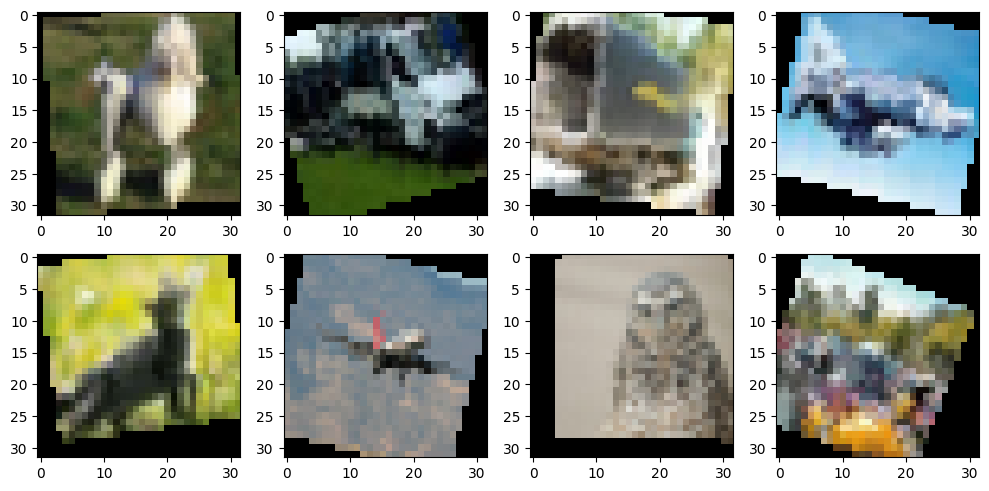

In [32]:
# one batch; the training loop below uses this dataloader
for (x_batch, y_batch) in train_dataloader:
    print('X:', type(x_batch), x_batch.shape)
    print('y:', type(y_batch), y_batch.shape)
    plt.figure(figsize=(10, 5))
    for i, img in enumerate(x_batch.numpy()[:8]):
        plt.subplot(2, 4, i+1)
        plt.imshow(np.clip(img.transpose([1,2,0]) * stds + means, 0, 1))
    plt.tight_layout()
    plt.show()
    break

When testing, we don't need random crops, just normalize with same statistics.

In [33]:
transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(means, stds),
])

test_loader = CIFAR10("./cifar_data/", train=False, transform=transform_test)
test_dataloader = torch.utils.data.DataLoader(test_loader, batch_size=500, shuffle=False)

In [34]:
# training the same small cnn from scratch with augmented images
set_seed()
model = nn.Sequential(
    nn.Conv2d(3, 10, kernel_size=3),
    nn.BatchNorm2d(10),
    nn.ReLU(),
    nn.MaxPool2d(2),
    nn.Flatten(),
    nn.Linear(10 * 15 * 15, 100),
    nn.ReLU(),
    nn.Dropout(0.1),
    nn.Linear(100, 10)
).to(device)
opt = torch.optim.Adam(model.parameters(), lr=0.001)

In [35]:
# kept the original training loop for this experiment
import time
num_epochs = 10 # total amount of full passes over training data
batch_size = 128  # number of samples processed in one SGD iteration
loss_history = []
accuracy_history = []
experiment_best = 0.0

for epoch in range(num_epochs):
    # In each epoch, we do a full pass over the training data:
    start_time = time.time()
    train_loss = []
    val_accuracy = []
    model.train(True) # enable dropout / batch_norm training behavior
    for X_batch, y_batch in train_dataloader:
        # train on batch
        loss = compute_loss(X_batch, y_batch)
        loss.backward()
        opt.step()
        opt.zero_grad()
        train_loss.append(loss.item() * len(y_batch))  # .item() = convert 1-value Tensor to float

    # And a full pass over the validation data:
    model.train(False)     # disable dropout / use averages for batch_norm
    with torch.no_grad():  # do not store intermediate activations
        for X_batch, y_batch in iterate_minibatches(X_val_normalized, y_val, batch_size):
            logits = model(torch.as_tensor(X_batch, dtype=torch.float32, device=device))
            y_pred = logits.argmax(-1).detach().cpu().numpy()
            val_accuracy.append(np.sum(y_batch == y_pred))

    # counted samples so the smaller last batch has the right weight
    epoch_loss = np.sum(train_loss) / len(X_train)
    epoch_accuracy = np.sum(val_accuracy) / len(X_val)
    loss_history.append(epoch_loss)
    accuracy_history.append(epoch_accuracy)
    experiment_best = max(experiment_best, epoch_accuracy)
    # kept the best model in memory and choose it using validation only
    if epoch_accuracy > best_accuracy:
        best_accuracy = epoch_accuracy
        best_model = copy.deepcopy(model)
        best_name = 'augmentation'
        best_epoch = epoch + 1

    # Then we print the results for this epoch:
    print("Epoch {} of {} took {:.3f}s".format(
        epoch + 1, num_epochs, time.time() - start_time))
    print("  training loss (in-iteration): \t{:.6f}".format(epoch_loss))
    print("  validation accuracy: \t\t\t{:.2f} %".format(epoch_accuracy * 100))

results.append(('augmentation', experiment_best))

Epoch 1 of 10 took 6.855s
  training loss (in-iteration): 	1.820468
  validation accuracy: 			39.26 %
Epoch 2 of 10 took 6.339s
  training loss (in-iteration): 	1.631149
  validation accuracy: 			43.09 %
Epoch 3 of 10 took 6.459s
  training loss (in-iteration): 	1.569342
  validation accuracy: 			45.60 %
Epoch 4 of 10 took 7.206s
  training loss (in-iteration): 	1.540062
  validation accuracy: 			47.91 %
Epoch 5 of 10 took 6.570s
  training loss (in-iteration): 	1.522411
  validation accuracy: 			47.68 %
Epoch 6 of 10 took 6.123s
  training loss (in-iteration): 	1.500379
  validation accuracy: 			48.65 %
Epoch 7 of 10 took 6.419s
  training loss (in-iteration): 	1.480980
  validation accuracy: 			49.36 %
Epoch 8 of 10 took 6.022s
  training loss (in-iteration): 	1.468257
  validation accuracy: 			47.71 %
Epoch 9 of 10 took 5.934s
  training loss (in-iteration): 	1.460356
  validation accuracy: 			49.50 %
Epoch 10 of 10 took 5.975s
  training loss (in-iteration): 	1.458354
  validation 

# Homework 2.2: The Quest For A Better Network

In this assignment you will build a monster network to solve CIFAR10 image classification.

This notebook is intended as a sequel to seminar 3, please give it a try if you haven't done so yet.

(please read it at least diagonally)

* The ultimate quest is to create a network that has as high __accuracy__ as you can push it.
* There is a __mini-report__ at the end that you will have to fill in. We recommend reading it first and filling it while you iterate.

## Grading
* starting at zero points
* +20% for describing your iteration path in a report below.
* +20% for building a network that gets above 20% accuracy
* +10% for beating each of these milestones on __TEST__ dataset:
    * 50% (50% points)
    * 60% (60% points)
    * 65% (70% points)
    * 70% (80% points)
    * 75% (90% points)
    * 80% (full points)
    
## Restrictions
* Please do NOT use pre-trained networks for this assignment until you reach 80%.
 * In other words, base milestones must be beaten without pre-trained nets (and such net must be present in the e-mail). After that, you can use whatever you want.
* you __can__ use validation data for training, but you __can't'__ do anything with test data apart from running the evaluation procedure.

## Tips on what can be done:


 * __Network size__
   * MOAR neurons,
   * MOAR layers, ([torch.nn docs](http://pytorch.org/docs/master/nn.html))

   * Nonlinearities in the hidden layers
     * tanh, relu, leaky relu, etc
   * Larger networks may take more epochs to train, so don't discard your net just because it could didn't beat the baseline in 5 epochs.

   * Ph'nglui mglw'nafh Cthulhu R'lyeh wgah'nagl fhtagn!


### The main rule of prototyping: one change at a time
   * By now you probably have several ideas on what to change. By all means, try them out! But there's a catch: __never test several new things at once__.


### Optimization
   * Training for 100 epochs regardless of anything is probably a bad idea.
   * Some networks converge over 5 epochs, others - over 500.
   * Way to go: stop when validation score is 10 iterations past maximum
   * You should certainly use adaptive optimizers
     * rmsprop, nesterov_momentum, adam, adagrad and so on.
     * Converge faster and sometimes reach better optima
     * It might make sense to tweak learning rate/momentum, other learning parameters, batch size and number of epochs
   * __BatchNormalization__ (nn.BatchNorm2d) for the win!
     * Sometimes more batch normalization is better.
   * __Regularize__ to prevent overfitting
     * Add some L2 weight norm to the loss function, PyTorch will do the rest
       * Can be done manually or with weight_decay parameter of a optimizer ([for example SGD's doc](https://pytorch.org/docs/stable/optim.html#torch.optim.SGD)).
     * Dropout (`nn.Dropout`) - to prevent overfitting
       * Don't overdo it. Check if it actually makes your network better
   
### Convolution architectures
   * This task __can__ be solved by a sequence of convolutions and poolings with batch_norm and ReLU seasoning, but you shouldn't necessarily stop there.
   * [Inception family](https://hacktilldawn.com/2016/09/25/inception-modules-explained-and-implemented/), [ResNet family](https://towardsdatascience.com/an-overview-of-resnet-and-its-variants-5281e2f56035?gi=9018057983ca), [Densely-connected convolutions (exotic)](https://arxiv.org/abs/1608.06993), [Capsule networks (exotic)](https://arxiv.org/abs/1710.09829)
   * Please do try a few simple architectures before you go for resnet-152.
   * Warning! Training convolutional networks can take long without GPU. That's okay.
     * If you are CPU-only, we still recomment that you try a simple convolutional architecture
     * a perfect option is if you can set it up to run at nighttime and check it up at the morning.
     * Make reasonable layer size estimates. A 128-neuron first convolution is likely an overkill.
     * __To reduce computation__ time by a factor in exchange for some accuracy drop, try using __stride__ parameter. A stride=2 convolution should take roughly 1/4 of the default (stride=1) one.

   
### Data augmemntation
   * getting 5x as large dataset for free is a great
     * Zoom-in+slice = move
     * Rotate+zoom(to remove black stripes)
     * Add Noize (gaussian or bernoulli)
   * Simple way to do that (if you have PIL/Image):
     * ```from scipy.misc import imrotate,imresize```
     * and a few slicing
     * Other cool libraries: cv2, skimake, PIL/Pillow
   * A more advanced way is to use torchvision transforms:
    ```
    transform_train = transforms.Compose([
        transforms.RandomCrop(32, padding=4),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
    ])
    trainset = torchvision.datasets.CIFAR10(root=path_to_cifar_like_in_seminar, train=True, download=True, transform=transform_train)
    trainloader = torch.utils.data.DataLoader(trainset, batch_size=128, shuffle=True, num_workers=2)

    ```
   * Or use this tool from Keras (requires theano/tensorflow): [tutorial](https://blog.keras.io/building-powerful-image-classification-models-using-very-little-data.html), [docs](https://keras.io/preprocessing/image/)
   * Stay realistic. There's usually no point in flipping dogs upside down as that is not the way you usually see them.
   
```

```

```

```

```

```

```

```


In [36]:
# you might as well write your solution here :)
# added three convolutional blocks and keep the same training settings
set_seed()
model = nn.Sequential(
    nn.Conv2d(3, 32, 3, padding=1),
    nn.BatchNorm2d(32),
    nn.ReLU(),
    nn.Conv2d(32, 32, 3, padding=1),
    nn.BatchNorm2d(32),
    nn.ReLU(),
    nn.MaxPool2d(2),
    nn.Conv2d(32, 64, 3, padding=1),
    nn.BatchNorm2d(64),
    nn.ReLU(),
    nn.Conv2d(64, 64, 3, padding=1),
    nn.BatchNorm2d(64),
    nn.ReLU(),
    nn.MaxPool2d(2),
    nn.Conv2d(64, 128, 3, padding=1),
    nn.BatchNorm2d(128),
    nn.ReLU(),
    nn.Conv2d(128, 128, 3, padding=1),
    nn.BatchNorm2d(128),
    nn.ReLU(),
    nn.MaxPool2d(2),
    nn.Flatten(),
    nn.Linear(128 * 4 * 4, 100),
    nn.ReLU(),
    nn.Dropout(0.1),
    nn.Linear(100, 10)
).to(device)
opt = torch.optim.Adam(model.parameters(), lr=0.001)

In [37]:
# kept the original training loop for this experiment
import time
num_epochs = 10 # total amount of full passes over training data
batch_size = 128  # number of samples processed in one SGD iteration
loss_history = []
accuracy_history = []
experiment_best = 0.0

for epoch in range(num_epochs):
    # In each epoch, we do a full pass over the training data:
    start_time = time.time()
    train_loss = []
    val_accuracy = []
    model.train(True) # enable dropout / batch_norm training behavior
    for X_batch, y_batch in train_dataloader:
        # train on batch
        loss = compute_loss(X_batch, y_batch)
        loss.backward()
        opt.step()
        opt.zero_grad()
        train_loss.append(loss.item() * len(y_batch))  # .item() = convert 1-value Tensor to float

    # And a full pass over the validation data:
    model.train(False)     # disable dropout / use averages for batch_norm
    with torch.no_grad():  # do not store intermediate activations
        for X_batch, y_batch in iterate_minibatches(X_val_normalized, y_val, batch_size):
            logits = model(torch.as_tensor(X_batch, dtype=torch.float32, device=device))
            y_pred = logits.argmax(-1).detach().cpu().numpy()
            val_accuracy.append(np.sum(y_batch == y_pred))

    # counted samples so the smaller last batch has the right weight
    epoch_loss = np.sum(train_loss) / len(X_train)
    epoch_accuracy = np.sum(val_accuracy) / len(X_val)
    loss_history.append(epoch_loss)
    accuracy_history.append(epoch_accuracy)
    experiment_best = max(experiment_best, epoch_accuracy)
    # kept the best model in memory and choose it using validation only
    if epoch_accuracy > best_accuracy:
        best_accuracy = epoch_accuracy
        best_model = copy.deepcopy(model)
        best_name = 'deeper_cnn'
        best_epoch = epoch + 1

    # Then we print the results for this epoch:
    print("Epoch {} of {} took {:.3f}s".format(
        epoch + 1, num_epochs, time.time() - start_time))
    print("  training loss (in-iteration): \t{:.6f}".format(epoch_loss))
    print("  validation accuracy: \t\t\t{:.2f} %".format(epoch_accuracy * 100))

results.append(('deeper_cnn', experiment_best))

Epoch 1 of 10 took 17.000s
  training loss (in-iteration): 	1.584449
  validation accuracy: 			51.93 %
Epoch 2 of 10 took 16.231s
  training loss (in-iteration): 	1.261520
  validation accuracy: 			59.90 %
Epoch 3 of 10 took 16.392s
  training loss (in-iteration): 	1.129195
  validation accuracy: 			66.76 %
Epoch 4 of 10 took 16.127s
  training loss (in-iteration): 	1.038504
  validation accuracy: 			70.14 %
Epoch 5 of 10 took 15.868s
  training loss (in-iteration): 	0.963012
  validation accuracy: 			71.01 %
Epoch 6 of 10 took 16.400s
  training loss (in-iteration): 	0.907886
  validation accuracy: 			71.68 %
Epoch 7 of 10 took 16.250s
  training loss (in-iteration): 	0.859277
  validation accuracy: 			71.36 %
Epoch 8 of 10 took 16.746s
  training loss (in-iteration): 	0.822984
  validation accuracy: 			75.44 %
Epoch 9 of 10 took 16.058s
  training loss (in-iteration): 	0.788577
  validation accuracy: 			76.49 %
Epoch 10 of 10 took 20.260s
  training loss (in-iteration): 	0.766558
  v

### longer training

Continue the last deeper CNN for 25 more epochs. Keep its optimizer, learning rate and augmentation unchanged, so this step changes only the training duration.

In [38]:
# kept the original training loop for this experiment
import time
num_epochs = 25 # total amount of full passes over training data
batch_size = 128  # number of samples processed in one SGD iteration
loss_history = []
accuracy_history = []
experiment_best = 0.0

for epoch in range(num_epochs):
    # In each epoch, we do a full pass over the training data:
    start_time = time.time()
    train_loss = []
    val_accuracy = []
    model.train(True) # enable dropout / batch_norm training behavior
    for X_batch, y_batch in train_dataloader:
        # train on batch
        loss = compute_loss(X_batch, y_batch)
        loss.backward()
        opt.step()
        opt.zero_grad()
        train_loss.append(loss.item() * len(y_batch))  # .item() = convert 1-value Tensor to float

    # And a full pass over the validation data:
    model.train(False)     # disable dropout / use averages for batch_norm
    with torch.no_grad():  # do not store intermediate activations
        for X_batch, y_batch in iterate_minibatches(X_val_normalized, y_val, batch_size):
            logits = model(torch.as_tensor(X_batch, dtype=torch.float32, device=device))
            y_pred = logits.argmax(-1).detach().cpu().numpy()
            val_accuracy.append(np.sum(y_batch == y_pred))

    # counted samples so the smaller last batch has the right weight
    epoch_loss = np.sum(train_loss) / len(X_train)
    epoch_accuracy = np.sum(val_accuracy) / len(X_val)
    loss_history.append(epoch_loss)
    accuracy_history.append(epoch_accuracy)
    experiment_best = max(experiment_best, epoch_accuracy)
    # kept the best model in memory and choose it using validation only
    if epoch_accuracy > best_accuracy:
        best_accuracy = epoch_accuracy
        best_model = copy.deepcopy(model)
        best_name = 'longer_training'
        best_epoch = epoch + 1

    # Then we print the results for this epoch:
    print("Epoch {} of {} took {:.3f}s".format(
        epoch + 1, num_epochs, time.time() - start_time))
    print("  training loss (in-iteration): \t{:.6f}".format(epoch_loss))
    print("  validation accuracy: \t\t\t{:.2f} %".format(epoch_accuracy * 100))

results.append(('longer_training', experiment_best))

Epoch 1 of 25 took 17.552s
  training loss (in-iteration): 	0.739032
  validation accuracy: 			78.92 %
Epoch 2 of 25 took 16.318s
  training loss (in-iteration): 	0.712849
  validation accuracy: 			79.08 %
Epoch 3 of 25 took 16.570s
  training loss (in-iteration): 	0.697127
  validation accuracy: 			79.78 %
Epoch 4 of 25 took 16.564s
  training loss (in-iteration): 	0.674805
  validation accuracy: 			77.82 %
Epoch 5 of 25 took 21.626s
  training loss (in-iteration): 	0.651677
  validation accuracy: 			81.43 %
Epoch 6 of 25 took 23.972s
  training loss (in-iteration): 	0.643932
  validation accuracy: 			80.81 %
Epoch 7 of 25 took 21.973s
  training loss (in-iteration): 	0.622956
  validation accuracy: 			81.38 %
Epoch 8 of 25 took 20.475s
  training loss (in-iteration): 	0.609683
  validation accuracy: 			79.80 %
Epoch 9 of 25 took 17.213s
  training loss (in-iteration): 	0.600054
  validation accuracy: 			82.73 %
Epoch 10 of 25 took 19.739s
  training loss (in-iteration): 	0.583177
  v

dense: validation accuracy = 49.83%
small_cnn: validation accuracy = 62.51%
batch_norm: validation accuracy = 64.05%
augmentation: validation accuracy = 50.36%
deeper_cnn: validation accuracy = 79.15%
longer_training: validation accuracy = 84.72%
selected model: longer_training, epoch 20


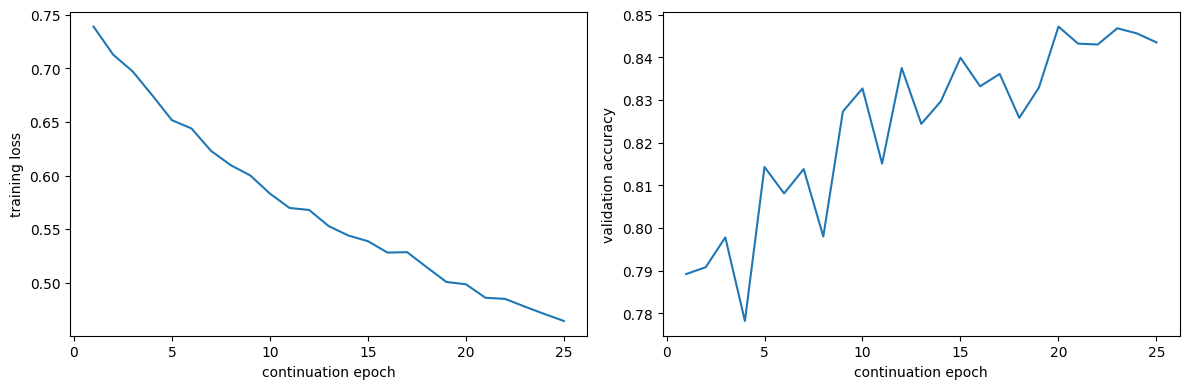

In [39]:
# compared the best validation score from each experiment
for name, accuracy in results:
    print(f'{name}: validation accuracy = {accuracy:.2%}')
print(f'selected model: {best_name}, epoch {best_epoch}')

# these curves show the last 25 epochs of the deeper model
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(range(1, len(loss_history) + 1), loss_history)
plt.xlabel('continuation epoch')
plt.ylabel('training loss')
plt.subplot(1, 2, 2)
plt.plot(range(1, len(accuracy_history) + 1), accuracy_history)
plt.xlabel('continuation epoch')
plt.ylabel('validation accuracy')
plt.tight_layout()
plt.show()

### final test

Evaluate the model selected using validation. Do not use the test score to choose further changes.

In [ ]:
model = best_model
model.train(False) # disable dropout / use averages for batch_norm
test_batch_acc = []
with torch.no_grad():
    for X_batch, y_batch in test_dataloader:
        logits = model(X_batch.to(device))
        y_pred = logits.argmax(1).cpu().numpy()
        test_batch_acc.append(np.mean(y_batch.numpy() == y_pred))

test_accuracy = np.mean(test_batch_acc)

print("Final results:")
print("  test accuracy:\t\t{:.2f} %".format(
    test_accuracy * 100))

if test_accuracy * 100 > 95:
    print("Double-check, than consider applying for NIPS'17. SRSly.")
elif test_accuracy * 100 > 90:
    print("U'r freakin' amazin'!")
elif test_accuracy * 100 > 80:
    print("Achievement unlocked: 110lvl Warlock!")
elif test_accuracy * 100 > 70:
    print("Achievement unlocked: 80lvl Warlock!")
elif test_accuracy * 100 > 60:
    print("Achievement unlocked: 70lvl Warlock!")
elif test_accuracy * 100 > 50:
    print("Achievement unlocked: 60lvl Warlock!")
else:
    print("We need more magic! Follow instructons below")

Final results:
  test accuracy:		84.07 %
Achievement unlocked: 110lvl Warlock!


## mini-report

I kept the original minibatch training loop and used the same 40,000 training images and 10,000 validation images in every experiment. I used the original SGD optimizer for the dense baseline and switched to Adam for the small CNN as requested in Task I. The test set is evaluated only after selecting the best model on validation.

I moved the original final test block from immediately after the dense baseline to the end of all experiments. Its previous location now prints `experiment_best`, the highest validation accuracy reached during baseline training, rather than test accuracy or the last epoch's validation accuracy. This keeps model selection based on validation scores and reserves the test score for the final evaluation, without using it to guide further changes. Moving the block was my choice, not an explicit assignment requirement.

I kept the structure of the teacher's loop, but changed two training settings. The original values were `num_epochs = 100` and `batch_size = 50`. I set `num_epochs = 10` for the initial experiments to reduce the total training time. The notebook suggests stopping after 5–20 epochs if validation accuracy stops improving, but my fixed 10-epoch runs are a training budget, not early stopping based on convergence.

I changed `batch_size` from 50 to 128 to process more images per step and aim for faster training on the GPU. All six experiments use batches of 128. This also reduces the number of optimizer updates per epoch and can affect accuracy, so it is not just a speed setting. I did not compare batches of 50 and 128 separately or measure the speedup. These settings were my choices, not assignment requirements, and their individual effects have not been established. The last experiment extends training by 25 epochs while keeping the batch size unchanged.

1. Train the original dense network for 10 epochs.
2. Replace it with the small CNN from Task I and train it with Adam for 10 epochs.
3. Add batch normalization and keep the other settings unchanged.
4. Train the same small CNN with the supplied random crops, rotations and horizontal flips.
5. Add more convolutional layers, keeping augmentation and the 10-epoch training budget.
6. Continue the deeper CNN for 25 more epochs without changing the optimizer or learning rate.

The printed comparison shows the best validation accuracy for each experiment. The final test block evaluates the best validation model. The two plots show the continuation run, not the entire training history.

### results and conclusions

| experiment | best validation accuracy |
| --- | ---: |
| dense baseline | 49.83% |
| small cnn | 62.51% |
| small cnn with batch normalization | 64.05% |
| small cnn with batch normalization and augmentation | 50.36% |
| deeper cnn with augmentation, 10 epochs | 79.15% |
| deeper cnn, 25 additional epochs | 84.72% |

The small CNN performed better than the dense baseline. I also switched from SGD to Adam in that step, as requested, so this comparison does not isolate the effect of convolutions. Adding batch normalization improved validation accuracy from 62.51% to 64.05%.

Augmentation reduced the small CNN's validation accuracy to 50.36% after 10 epochs. These transformations made the training task harder, and the small model did not benefit within this training budget. This result does not mean augmentation is always harmful. The deeper CNN reached 79.15% with the same augmentation, and continuing its training increased the best validation accuracy to 84.72%.

The selected model came from epoch 20 of the continuation run, or epoch 30 in total, rather than the last training epoch. Its final test accuracy was **84.07%**, exceeding the 80% target without pretrained weights. These are the results saved in this version of the notebook. They come from one seeded run, so repeated runs may give slightly different scores.